In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
df = pd.read_csv("../dataset/student_performance.csv")

print(df.shape)

df.head()

(1000, 12)


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [3]:
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB

Missing Values:

StudentID                    40
Name   

In [4]:
df.drop_duplicates(inplace=True)

df.fillna(method='ffill', inplace=True)

print(df.shape)

(1000, 12)


/tmp/ipykernel_15347/196611929.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_15347/196611929.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(method='ffill', inplace=True)


Dataset shape: (1000, 12)
After cleaning: (1000, 12)

Model Performance:

               Model  R2 Score
0  Linear Regression -0.011734
1      Decision Tree -0.940213
2      Random Forest -0.061238


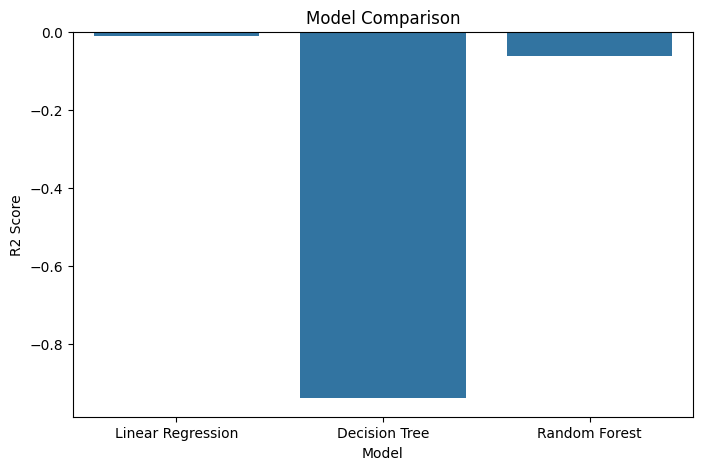

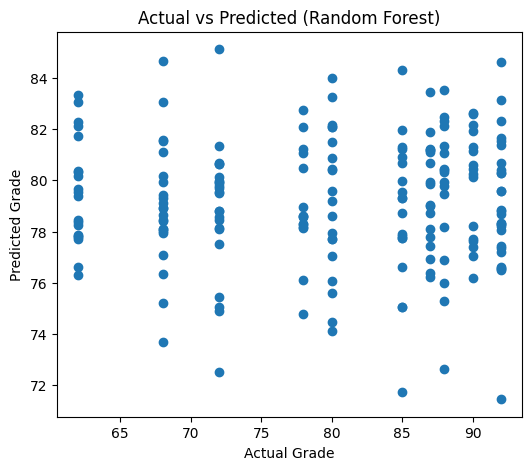


Feature Importance:

                     Feature  Importance
7             Attendance (%)    0.220479
6                Study Hours    0.199023
3              PreviousGrade    0.125199
2          StudyHoursPerWeek    0.124630
1             AttendanceRate    0.123925
4  ExtracurricularActivities    0.082614
5            ParentalSupport    0.060883
0                     Gender    0.033439
8       Online Classes Taken    0.029809


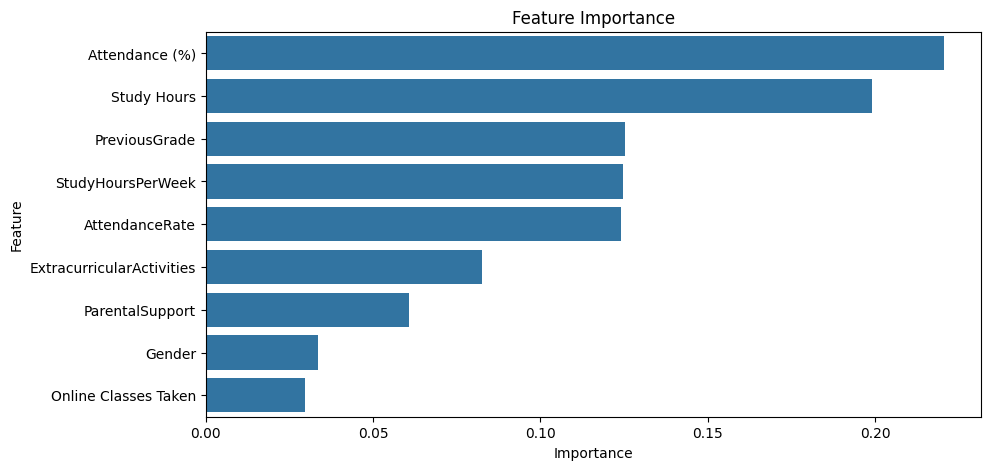


All models + dataset saved successfully!


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# -------------------------
# LOAD DATASET
# -------------------------
df = pd.read_csv("../dataset/student_performance.csv")

print("Dataset shape:", df.shape)

# -------------------------
# CLEANING
# -------------------------
df.drop_duplicates(inplace=True)
pd.set_option('future.no_silent_downcasting', True)
df = df.ffill()
df = df.infer_objects(copy=False)

print("After cleaning:", df.shape)

# -------------------------
# ENCODING
# -------------------------
le = LabelEncoder()

categorical_cols = ['Gender', 'ExtracurricularActivities', 'ParentalSupport']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# -------------------------
# SPLIT FEATURES
# -------------------------
X = df.drop(columns=['StudentID', 'Name', 'FinalGrade'])
y = df['FinalGrade']

# -------------------------
# TRAIN TEST SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# MODELS
# -------------------------
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# -------------------------
# PREDICTIONS
# -------------------------
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

# -------------------------
# EVALUATION
# -------------------------
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

print("\nModel Performance:\n")
print(results)

# -------------------------
# PLOT RESULTS
# -------------------------
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="R2 Score")
plt.title("Model Comparison")
plt.show()

# -------------------------
# ACTUAL VS PREDICTED
# -------------------------
plt.figure(figsize=(6,5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

# -------------------------
# FEATURE IMPORTANCE
# -------------------------
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n")
print(importance)

plt.figure(figsize=(10,5))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

# -------------------------
# SAVE MODELS & DATA
# -------------------------
joblib.dump(lr, "linear_regression.pkl")
joblib.dump(dt, "decision_tree.pkl")
joblib.dump(rf, "random_forest.pkl")

df.to_csv("student_cleaned.csv", index=False)

print("\nAll models + dataset saved successfully!")